In [3]:
from backtest_engine import request, Portfolio, PortfolioDynamicCost, StrategyConnector, generate_toy_equity
from datetime import date
import tomllib

with open("config.toml", "rb") as f:
    config = tomllib.load(f)["alpaca-api"]
    
df = request(
    ticker="SPY",
    config=config,
)

# todo: optimise pd -> np
# todo: consider refactoring tearsheet and connector into dataclasses

Loading data from local cache: cache_SPY_20170101_20260620.parquet


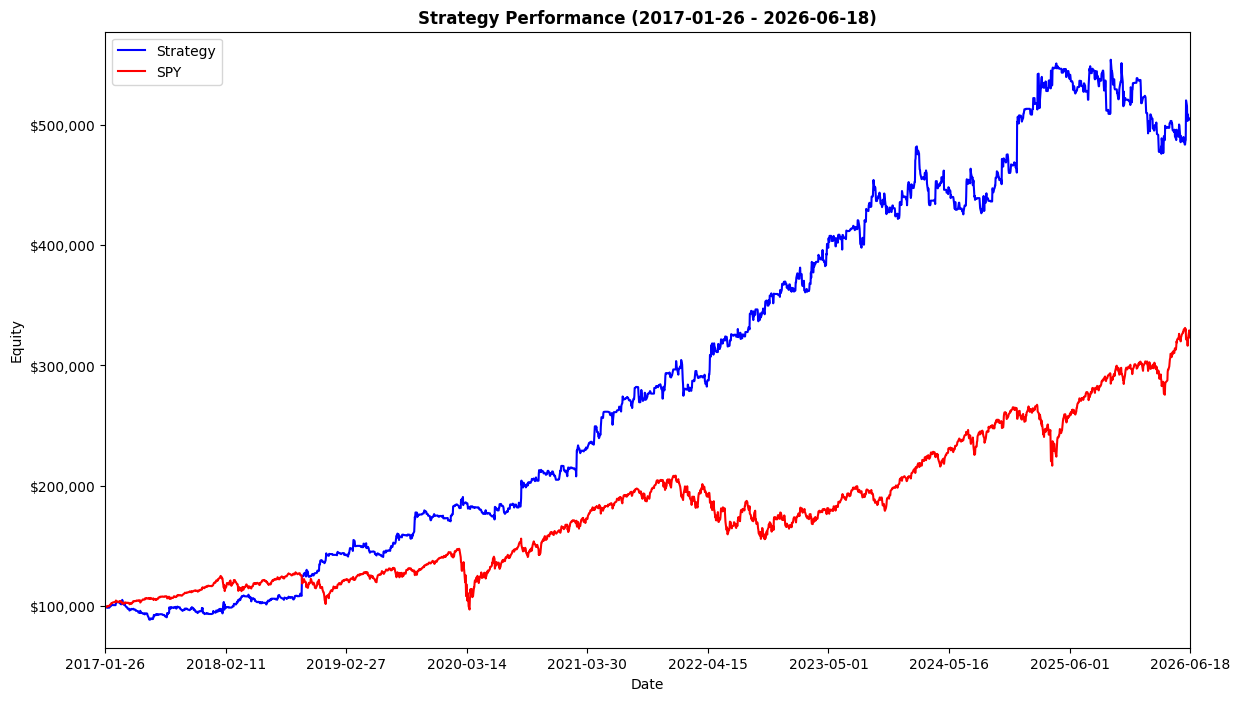

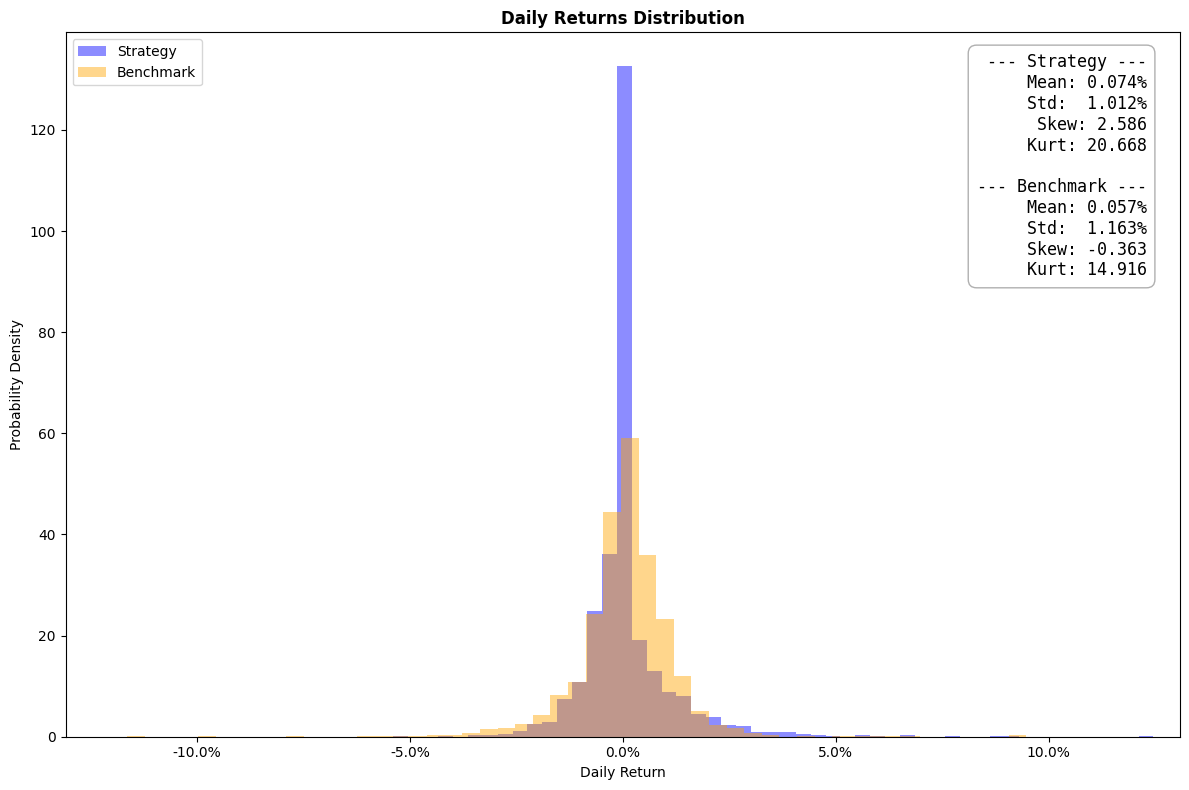

                                Strategy      Benchmark
Total Days                         2,362
Cum. Return                      404.60%        230.32%
Ann. Return                       18.85%         13.60%
Avg. Daily Return                  0.07%          0.06%
Ret. Skew                           2.59          -0.36
Ret. Kurtosis                      20.67          14.92
Max Gain                          12.46%          9.47%
Best Day                      2018-10-10     2020-03-24
Max Loss                          -5.39%        -11.63%
Worst Day                     2018-02-06     2020-03-16
Win Rate                          42.10%              -
Daily Win Rate                    29.68%         55.63%
Average Trades / Day                1.00              -
Average Return / Trade              0.00              -
Alpha                               0.20              -
Beta                               -0.10              -
R-Squared                           0.01              -
Ann. Vo

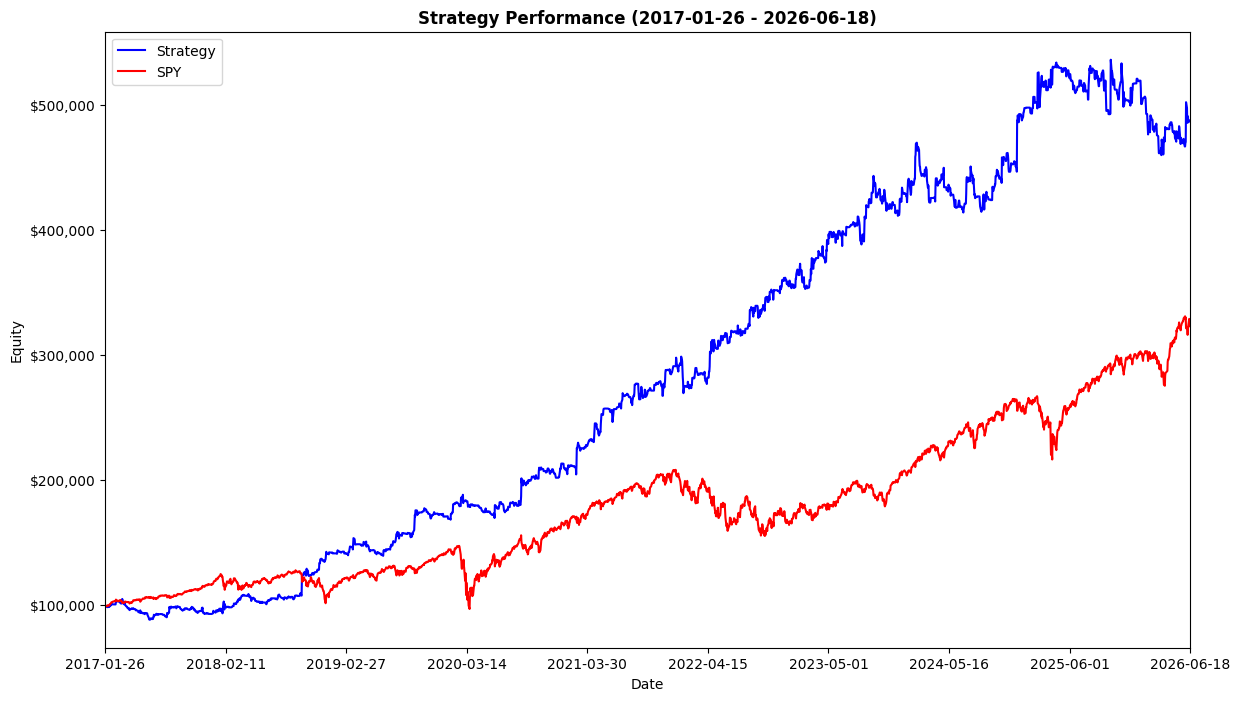

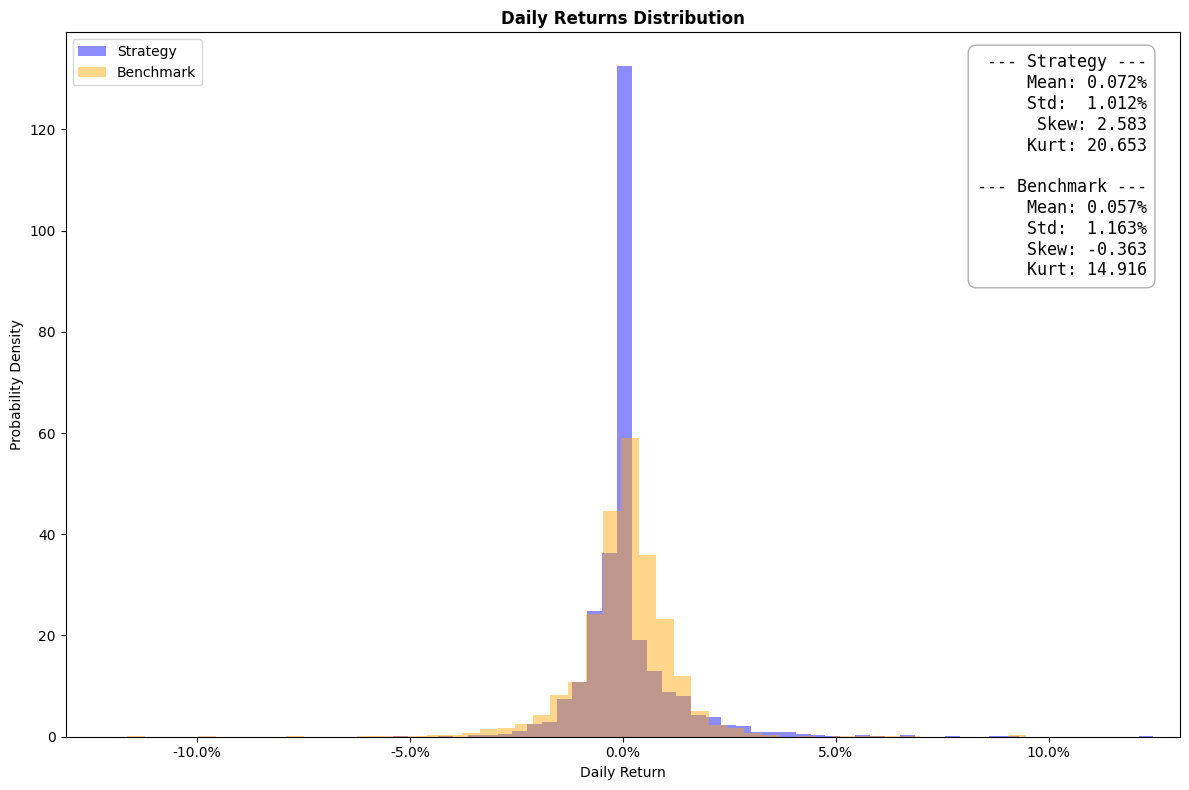

                                Strategy      Benchmark
Total Days                         2,362
Cum. Return                      387.20%        230.32%
Ann. Return                       18.41%         13.60%
Avg. Daily Return                  0.07%          0.06%
Ret. Skew                           2.58          -0.36
Ret. Kurtosis                      20.65          14.92
Max Gain                          12.46%          9.47%
Best Day                      2018-10-10     2020-03-24
Max Loss                          -5.39%        -11.63%
Worst Day                     2018-02-06     2020-03-16
Win Rate                          42.02%              -
Daily Win Rate                    29.59%         55.63%
Average Trades / Day                1.00              -
Average Return / Trade              0.00              -
Alpha                               0.20              -
Beta                               -0.10              -
R-Squared                           0.01              -
Ann. Vo

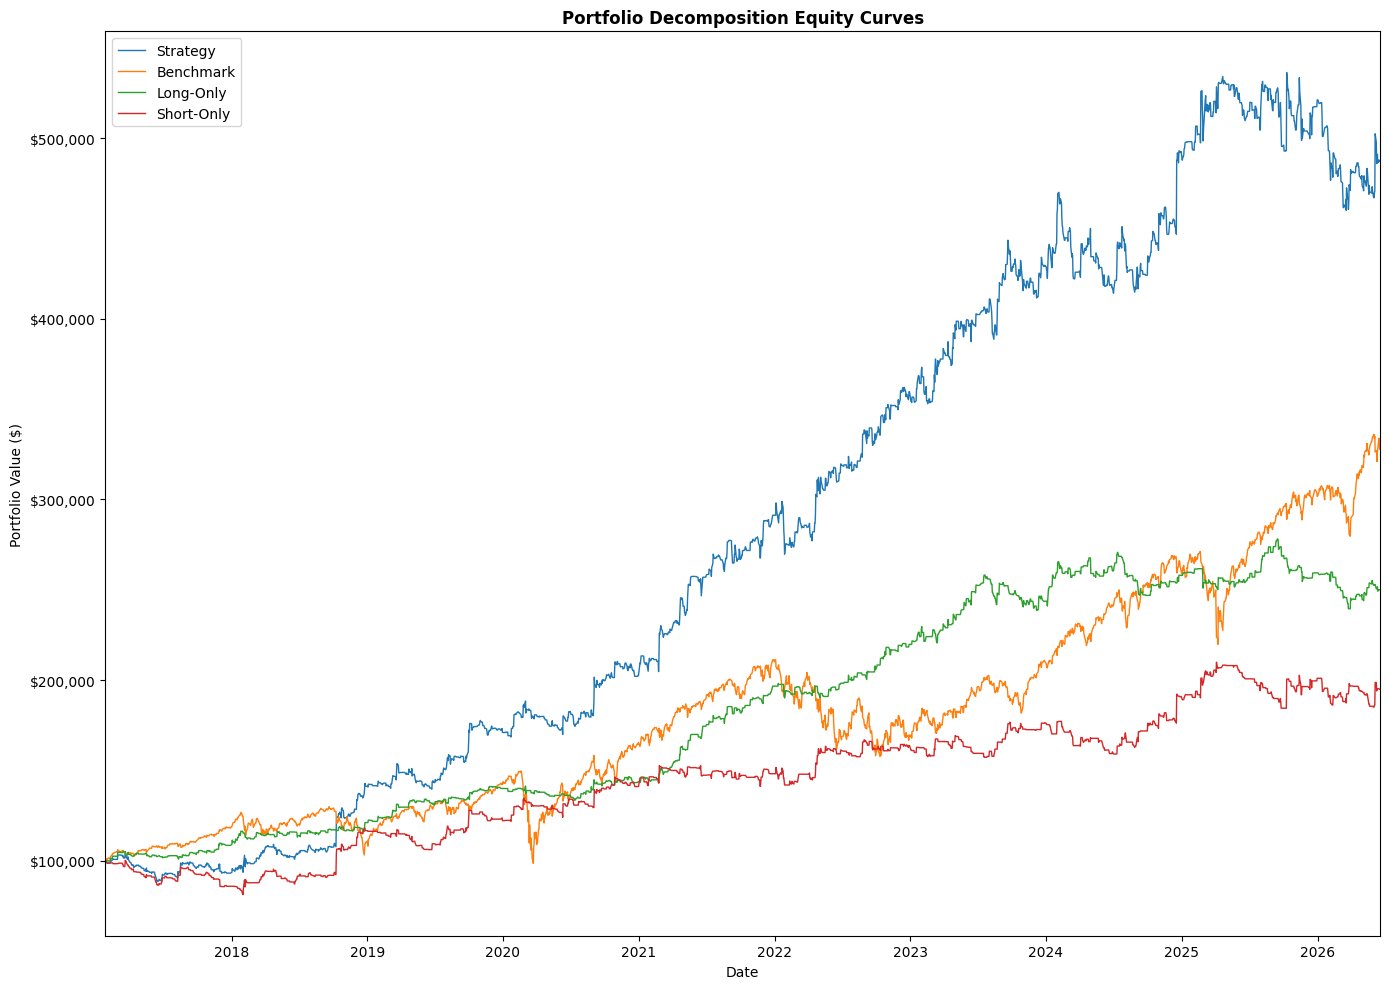

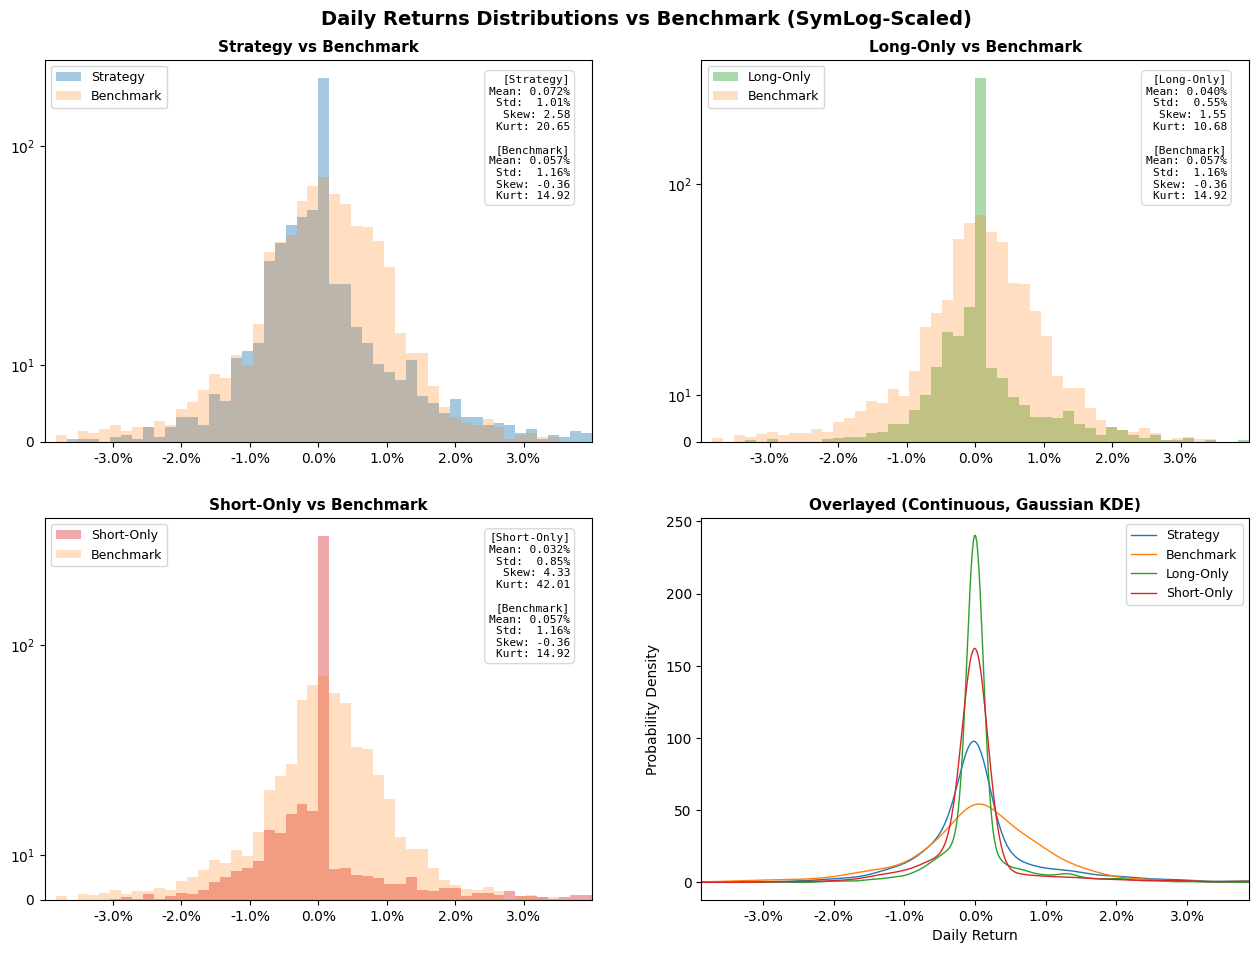

                                Strategy     Strat_Long     Short-Only      Benchmark
-------------------------------------------------------------------------------------
Total Days                         2,362          2,362          2,362              -
Cum. Return                      387.20%        150.03%         94.86%        230.32%
Ann. Return                       18.41%         10.27%          7.38%         13.60%
Avg. Daily Return                  0.07%          0.04%          0.03%          0.06%
Ret. Skew                           2.58           1.55           4.33          -0.36
Ret. Kurtosis                      20.65          10.68          42.01          14.92
Max Gain                          12.46%          4.21%         12.46%          9.47%
Best Day                      2018-10-10     2018-12-26     2018-10-10     2020-03-24
Max Loss                          -5.39%         -3.22%         -4.28%        -11.63%
Worst Day                     2018-02-06     2024-05-0

In [ ]:

pn = Portfolio(df)
p = PortfolioDynamicCost(df)

toy_book = generate_toy_equity(p, expected_return=0.15, volatility=0.075)

c = StrategyConnector(p, toy_book, df["close"])

print(pn.result())
print(p.result())
print(p.result(decompose=True)) 
# print(p.result(start=date(2020, 1, 1), end=date(2021, 1, 1)))
# print(p.result(day=date(2025, 4, 12)))


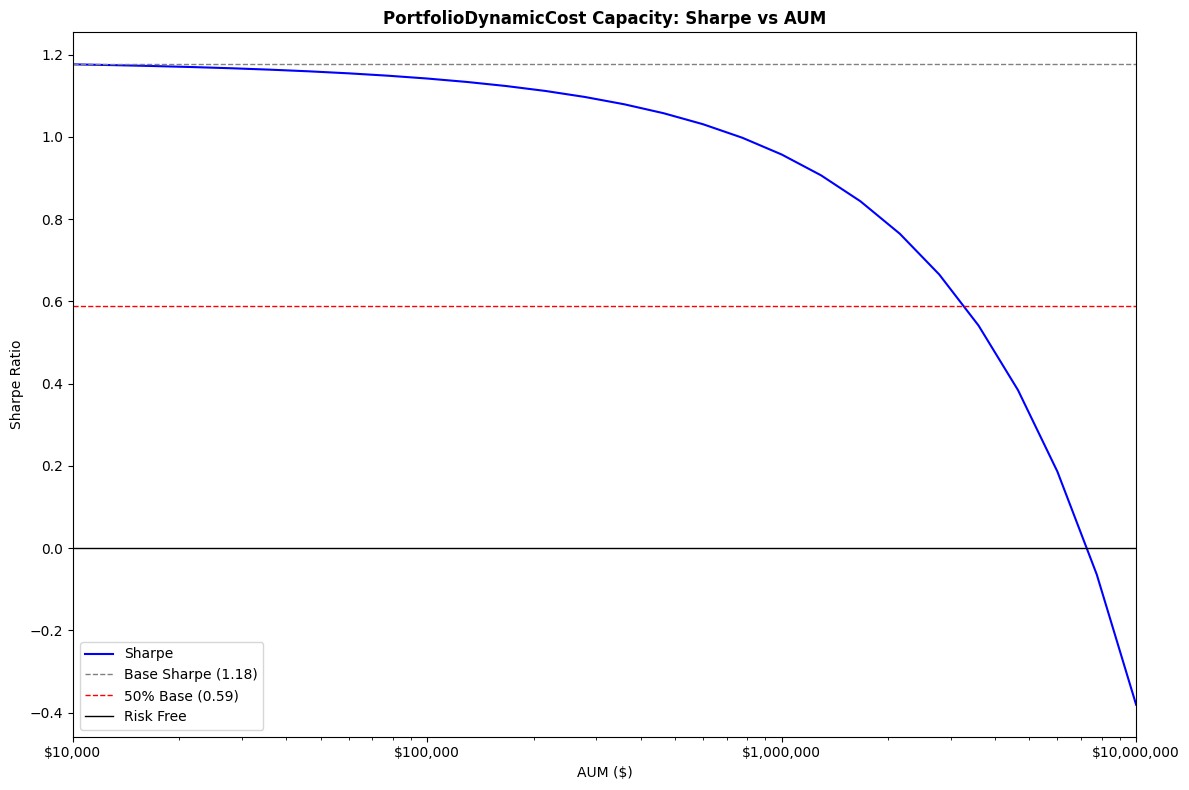

In [5]:
PortfolioDynamicCost.sharpe_curve(df, max_aum=10_000_000)

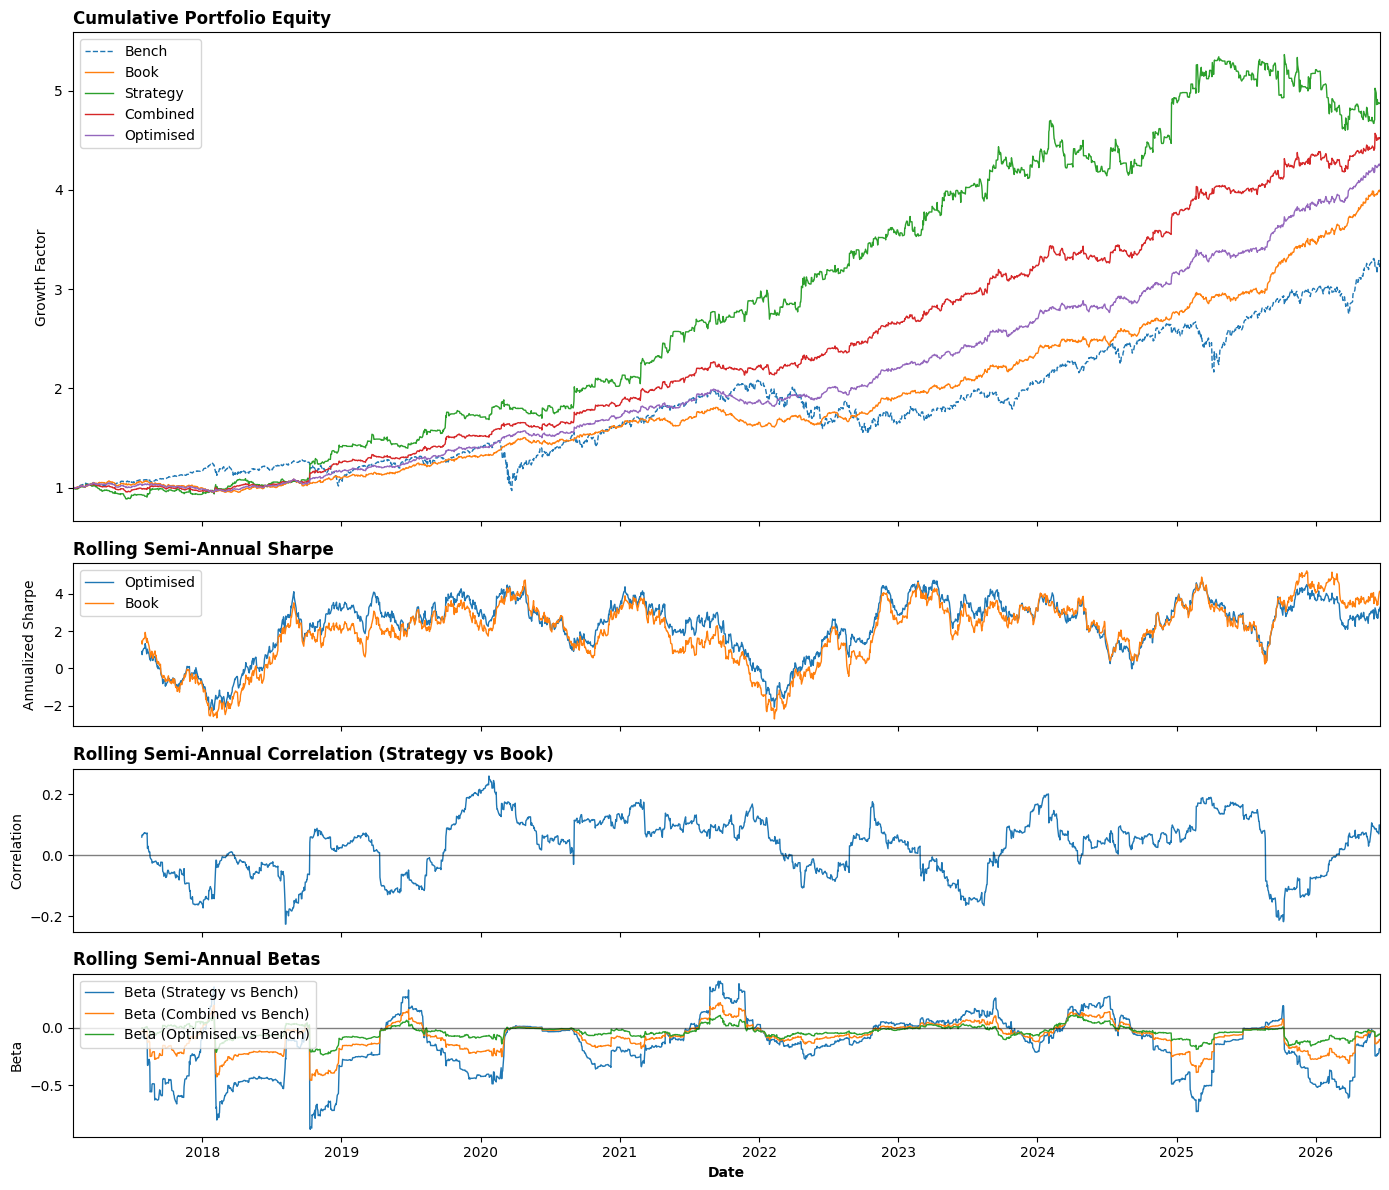

=== Portfolio Integration & Risk Report ===
                                 Book Strategy   Combined Optimised    Bench
Expected Return                15.03%   18.17%     16.49%    15.67%   14.30%
Volatility                      7.44%   16.07%      8.95%     6.85%   18.45%
Sharpe                           2.02     1.13       1.84      2.29     0.77
Beta                            -0.01    -0.10      -0.06     -0.03     1.00
Skewness                         0.01     2.58       2.01      0.38    -0.36
Kurtosis                         0.28    20.65      15.44      1.89    14.94
Max Drawdown                  -11.09%  -15.81%     -9.60%    -8.85%  -34.23%
Max DD Days                       288      255        340       350      512
Max DD Recovery Days              146      195        122       135      103
Correlation to Book                 -     0.03       0.44      0.88        -
Crash Correlation to Book           -     0.04       0.28      0.73        -
Intraday Correlation to Book    

In [6]:
c.result()